# Statistiques macrofinancières US

## Inflation

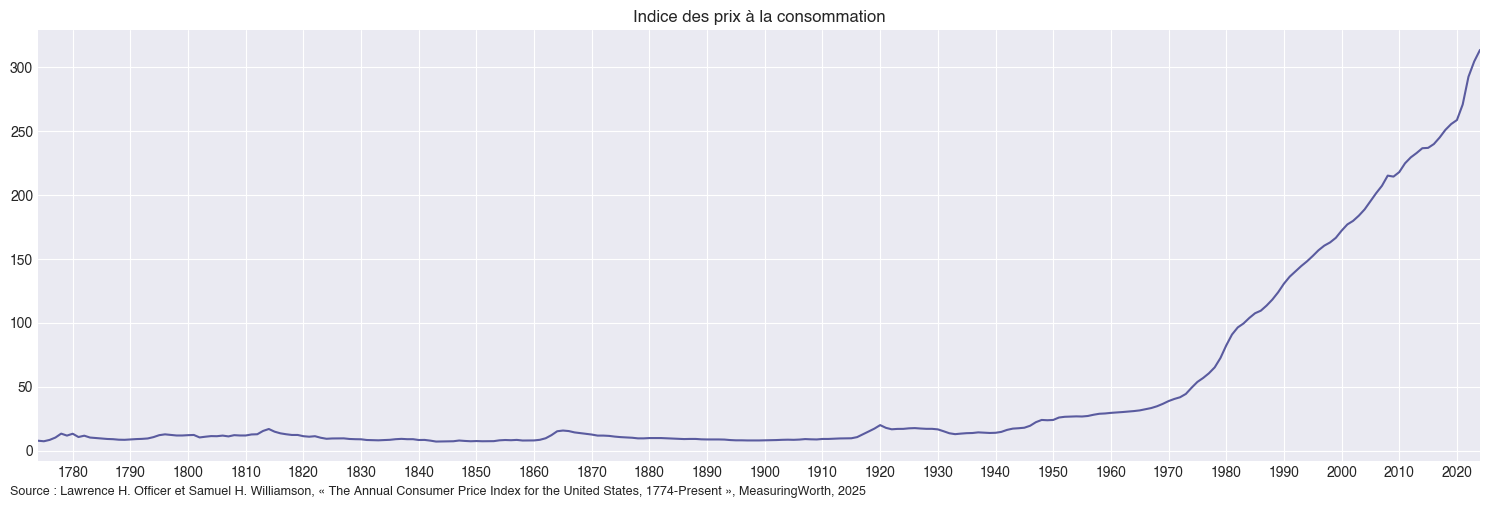

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

# Chargement du CSV
df = pd.read_csv("Data/USCPI_1774-2024.csv", skiprows=2)  # saute les lignes de citation
df["Year"] = df["Year"].astype(int)
df.set_index("Year", inplace=True)

# Conversion en Series
cpi = df["U.S. Consumer Price Index *"]
cpi.index.name = None

# Plot
fig, ax = plt.subplots(figsize=(15, 5))
cpi.plot()
ax.set_title("Indice des prix à la consommation")
ax.set_xmargin(0)
ax.xaxis.set_major_locator(MaxNLocator(nbins=30)) 
fig.text(0.01, -0.0, "Source : Lawrence H. Officer et Samuel H. Williamson, « The Annual Consumer Price Index for the United States, 1774-Present », MeasuringWorth, 2025", ha="left", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Chargement du CSV
df = pd.read_csv("Data/USCPI_1774-2024.csv", skiprows=2)  # saute les lignes de citation
df["Year"] = df["Year"].astype(int)
df.set_index("Year", inplace=True)

# Conversion en Series
cpi = df["U.S. Consumer Price Index *"]
cpi.index.name = None
def real_price(value,date=None,base=2024):
    if type(value) == list:
        l = []
        for i in value:
            l.append(float(i*cpi[base]/cpi[date]))
        return l
    elif type(value) == type(np.array([])):
        return value*cpi[base]/cpi[date]
    elif type(value) == type(pd.Series([])):
        return value/(cpi/cpi.loc[base])
    else:
        return float(value*cpi[base]/cpi[date])

## PIB

In [87]:
import numpy as np
import pandas as pd
df = pd.read_csv("Data/USGDP_1790-2024.csv", skiprows=1, thousands=',')
df = df.set_index('Year')
nominal_gdp = df['Nominal GDP (million of Dollars)']
real_gdp = df['Real GDP (millions of 2017 dollars)']